# Wind → data centre → electrolyser → tank → fuel cell

A dispatch model of the whole system, with hydrogen as **real storage** rather
than a flat supply chain. Every size is a parameter in `dashboard_config.py`.

### The dispatch rule, each timestep

1. **Wind serves the data centre first.** Whatever the turbines make goes
   straight to the servers, up to the data centre's demand.
2. **Surplus wind makes hydrogen.** Anything above the data centre's demand goes
   to the electrolyser, capped by the electrolyser's rating, and the hydrogen
   goes into the tank — capped by the room left in it. Wind that fits through
   neither cap is curtailed.
3. **When the wind falls short, the tank discharges.** The fuel cell converts
   stored hydrogen back to electricity to cover the gap, capped by its rating
   and by what is actually in the tank.
4. **If the tank runs dry, the grid covers the rest** (or the load goes unserved,
   if `SYS_ALLOW_GRID_BACKUP = False`).

This is materially different from
[4.2.datacentre_hydrogen.ipynb](4.2.datacentre_hydrogen.ipynb), where *all* the
wind went through the electrolyser and the data centre drew flat from hydrogen.
Here the wind is used directly wherever possible and only the surplus is stored,
so the 70% round-trip loss is paid on the stored fraction alone — which is the
configuration that actually makes engineering sense.

### What you set

| parameter | meaning |
|---|---|
| `SYS_DC_DEMAND_MW` | data centre continuous draw |
| `SYS_WIND_CAPACITY_MW` | wind farm at `WIND_LAT` / `WIND_LON` |
| `SYS_ELECTROLYSER_MW` | how fast surplus can be absorbed |
| `SYS_TANK_CAPACITY_T` | tonnes of H₂ the tank holds |
| `SYS_FUELCELL_MW` | discharge rating (`None` = match the data centre) |
| `SYS_START` / `SYS_END` | the period to simulate |

The tank inventory follows Gandiglio et al. (2022), who model a hydrogen
vessel as a mass of steel and nothing else — see notebook 2. Switch
`TANK_DESIGN` between their as-built 28 bar vessel (313 kg steel/kg H₂) and a
200 bar Type I bottle (100 kg/kg).

In [1]:
from dashboard_config import *
import dashboard_config as cfg
import lca_helpers as H
import bw2data as bd, bw2calc as bc
import numpy as np, pandas as pd

ei, bio, fg_db, method = H.setup_brightway()

GWP = next(m for m in bd.methods if m[1] == "IPCC 2021" and m[2] == "climate change"
           and "GWP100" in m[3] and "no LT" not in m[1])

def carbon(activity, amount=1.0):
    _l = bc.LCA({activity: amount}, GWP); _l.lci(); _l.lcia(); return _l.score

def background(name, location):
    hits = [a for a in ei if a.get("name") == name and a.get("location") == location]
    if len(hits) != 1:
        raise ValueError(f"Expected 1 match for {name!r} in {location}, got {len(hits)}")
    return hits[0]

print("System sizing")
print("-------------")
print(f"  data centre    {SYS_DC_DEMAND_MW:>8.2f} MW continuous")
print(f"  wind farm      {SYS_WIND_CAPACITY_MW:>8.2f} MW at {WIND_LAT}, {WIND_LON}")
print(f"  electrolyser   {SYS_ELECTROLYSER_MW:>8.2f} MW")
print(f"  fuel cell      {SYS_FUELCELL_MW:>8.2f} MW")
print(f"  tank           {SYS_TANK_CAPACITY_T:>8.1f} t H2  (starting {SYS_INITIAL_SOC_FRAC:.0%} full)")
print(f"  period         {SYS_START} → {SYS_END}")
print(f"  grid backup    {'yes' if SYS_ALLOW_GRID_BACKUP else 'no — shortfall reported as unserved'}")

/opt/miniconda3/envs/brightway/lib/python3.11/site-packages/bw2calc/__init__.py:54: UserWarning: 
It seems like you have an ARM architecture, but haven't installed scikit-umfpack:

    https://pypi.org/project/scikit-umfpack/

Installing it could give you much faster calculations.

  warnings.warn(UMFPACK_WARNING)


Current Brightway project: hydrogen-smr
Using ecoinvent database: ecoinvent-3.9.1-apos
Using biosphere database: ecoinvent-3.9.1-biosphere
Using foreground database: hydrogen foreground
Using LCIA method: ('ecoinvent-3.9.1', 'IPCC 2021 no LT', 'climate change no LT', 'global warming potential (GWP100) no LT')
System sizing
-------------
  data centre        7.31 MW continuous
  wind farm         50.00 MW at 51.732, -0.3711
  electrolyser      25.00 MW
  fuel cell          7.31 MW
  tank               10.0 t H2  (starting 50% full)
  period         2025-01-01 → 2025-12-31
  grid backup    yes


## Carbon factors

Each converter is split into the part that scales with electricity and the part
that doesn't, so the electricity can be priced at whatever the dispatch actually
delivered. All of it is read live from the foreground databases.

In [2]:
DC   = bd.get_activity((DC_FOREGROUND_DB, "dc_zhang_virginia_baseline_25y"))
FCOP = bd.get_activity((FC_FOREGROUND_DB, "pemfc_op_1kwh_h2"))
H2   = bd.get_activity(tuple(FC_H2_SOURCE))
TANK = bd.get_activity((H2_STORAGE_FOREGROUND_DB, "h2_tank_steel_1kg_capacity"))

# Data centre: non-electricity operation burden, expressed per kWh so it can be
# scaled to whatever data centre size is configured.
OPERATION_TAGS = ("IT + cooling/aux", "WUE", "backup gen", "refresh cycles",
                  "UPS", "cooling water treatment", "refrigerant top-up")
op_exc = [e for e in DC.technosphere()
          if any(t in (e.get("comment") or "") for t in OPERATION_TAGS)]
if len(op_exc) != len(OPERATION_TAGS):
    raise ValueError(f"Expected {len(OPERATION_TAGS)} operation exchanges, found {len(op_exc)}.")
elec_exc = [e for e in op_exc if H.is_any_electricity_exchange(e)]
if len(elec_exc) != 1:
    raise ValueError(f"Expected 1 operation electricity exchange, found {len(elec_exc)}.")
DC_REF_KWH        = elec_exc[0].amount / DC_OPERATION_YEARS
DC_OTHER_PER_KWH  = sum(carbon(e.input, e.amount / DC_OPERATION_YEARS)
                        for e in op_exc if e is not elec_exc[0]) / DC_REF_KWH

# Electrolyser and fuel cell: (electricity) + (everything else).
H2_FIXED_PER_KG, H2_KWH_PER_KG, _ = H.run_non_electricity_lca(H2, GWP)
FC_H2_PER_KWH_LIVE = sum(e.amount for e in FCOP.technosphere() if e.input.key == H2.key)
FC_FIXED_PER_KWH   = carbon(FCOP) - FC_H2_PER_KWH_LIVE * carbon(H2)

TANK_PER_KG_CAP = carbon(TANK)
CHARGE_KWH_PER_KG = H2_KWH_PER_KG + TANK_COMPRESSION_KWH_PER_KG

wind_bg, grid_bg = background(DC_H2_WIND_QUERY, DC_H2_WIND_LOC), background(DC_H2_GRID_QUERY, DC_H2_GRID_LOC)
CI_WIND, CI_GRID = carbon(wind_bg), carbon(grid_bg)

print(f"electrolyser  {H2_KWH_PER_KG:>6.1f} kWh/kg + {TANK_COMPRESSION_KWH_PER_KG:.1f} compression "
      f"= {CHARGE_KWH_PER_KG:.1f} kWh per kg stored | {H2_FIXED_PER_KG:.3f} kg CO2e/kg fixed")
print(f"fuel cell     {FC_H2_PER_KWH_LIVE:>6.5f} kg H2/kWh | {FC_FIXED_PER_KWH*1000:.1f} g CO2e/kWh fixed")
print(f"tank          {TANK_PER_KG_CAP:>6.1f} kg CO2e per kg of capacity ({TANK_DESIGN}), over {TANK_LIFETIME_YEARS} y")
print(f"data centre   {DC_OTHER_PER_KWH*1000:>6.2f} g CO2e/kWh for non-electricity operation")
print(f"electricity   wind {CI_WIND*1000:.1f} | grid {CI_GRID*1000:.1f} g CO2e/kWh")
print(f"\nRound trip through storage: {CHARGE_KWH_PER_KG * FC_H2_PER_KWH_LIVE:.2f} kWh in per kWh out "
      f"({100/(CHARGE_KWH_PER_KG*FC_H2_PER_KWH_LIVE):.1f}%)")

electrolyser    54.0 kWh/kg + 0.0 compression = 54.0 kWh per kg stored | 0.195 kg CO2e/kg fixed
fuel cell     0.06316 kg H2/kWh | 14.0 g CO2e/kWh fixed
tank          1594.6 kg CO2e per kg of capacity (gandiglio_28bar), over 25 y
data centre    13.13 g CO2e/kWh for non-electricity operation
electricity   wind 14.5 | grid 311.2 g CO2e/kWh

Round trip through storage: 3.41 kWh in per kWh out (29.3%)


## Wind for the chosen period

In [3]:
REFERENCE_KW = 1000.0   # only the capacity factor is kept

ninja = H.create_ninja_session()
wind_df, ninja_meta, ninja_args = H.fetch_ninja_wind(
    session=ninja, lat=WIND_LAT, lon=WIND_LON,
    date_from=SYS_START, date_to=SYS_END,
    capacity_kw=REFERENCE_KW, height_m=NINJA_HUB_HEIGHT_M,
    turbine=NINJA_TURBINE, dataset=NINJA_DATASET,
)
cf = wind_df["wind_capacity_factor"].to_numpy()
stamps = pd.to_datetime(wind_df.index)
DT_HOURS = float(pd.Series(stamps).diff().dropna().dt.total_seconds().median() / 3600.0)
SIM_HOURS = len(cf) * DT_HOURS
SIM_YEARS = SIM_HOURS / 8760.0

print(f"{NINJA_TURBINE} @ {NINJA_HUB_HEIGHT_M} m, {NINJA_DATASET} | {SYS_START} → {SYS_END}")
print(f"{len(cf):,} steps of {DT_HOURS:g} h = {SIM_HOURS:,.0f} h ({SIM_YEARS:.2f} y)")
print(f"capacity factor {cf.mean():.3f} | peak {cf.max():.2f} | steps below 5% {int((cf<0.05).sum()):,}")

Renewables.ninja session created. Source: environment; token length: 40


Status: 200
URL: https://www.renewables.ninja/api/data/wind?lat=51.732&lon=-0.3711&date_from=2025-01-01&date_to=2025-12-31&dataset=merra2&capacity=1000.0&height=80.0&turbine=Vestas+V90+2000&format=json
Vestas V90 2000 @ 80.0 m, merra2 | 2025-01-01 → 2025-12-31
8,760 steps of 1 h = 8,760 h (1.00 y)
capacity factor 0.349 | peak 0.99 | steps below 5% 577


## Dispatch

One pass over the period. The tank's state of charge carries between steps,
which is the whole point — it is what lets a windy Tuesday pay for a still
Friday.

In [4]:
dc_kw    = SYS_DC_DEMAND_MW     * 1000.0
wind_cap = SYS_WIND_CAPACITY_MW * 1000.0
ely_kw   = SYS_ELECTROLYSER_MW  * 1000.0
fc_kw    = SYS_FUELCELL_MW      * 1000.0
tank_kg  = SYS_TANK_CAPACITY_T  * 1000.0

n = len(cf)
soc = np.zeros(n)                      # kg H2 in the tank, end of each step
direct_kwh   = np.zeros(n)             # wind straight to the data centre
fc_kwh       = np.zeros(n)             # data centre served from stored hydrogen
grid_kwh     = np.zeros(n)             # data centre served from the grid
unserved_kwh = np.zeros(n)             # demand met by nothing (grid backup off)
curtail_kwh  = np.zeros(n)             # wind generated but not usable
h2_made      = np.zeros(n)             # kg into the tank
h2_used      = np.zeros(n)             # kg out of the tank
to_ely_kwh   = np.zeros(n)             # surplus wind actually electrolysed

level = SYS_INITIAL_SOC_FRAC * tank_kg
for t in range(n):
    wind_kw = cf[t] * wind_cap

    # 1. wind serves the data centre first
    direct_kw = min(wind_kw, dc_kw)
    direct_kwh[t] = direct_kw * DT_HOURS
    shortfall_kwh = (dc_kw - direct_kw) * DT_HOURS
    surplus_kwh   = (wind_kw - direct_kw) * DT_HOURS

    # 2. surplus makes hydrogen, limited by the electrolyser and by tank room
    if surplus_kwh > 0:
        usable_kwh = min(surplus_kwh, ely_kw * DT_HOURS)
        made       = usable_kwh / CHARGE_KWH_PER_KG
        stored     = min(made, tank_kg - level)
        used_kwh   = stored * CHARGE_KWH_PER_KG      # throttle if the tank is full
        level     += stored
        h2_made[t]    = stored
        to_ely_kwh[t] = used_kwh
        curtail_kwh[t] = surplus_kwh - used_kwh

    # 3. the tank covers what the wind could not
    if shortfall_kwh > 0:
        want_kwh = min(shortfall_kwh, fc_kw * DT_HOURS)
        need_kg  = want_kwh * FC_H2_PER_KWH_LIVE
        drawn    = min(need_kg, level)
        level   -= drawn
        h2_used[t] = drawn
        fc_kwh[t]  = drawn / FC_H2_PER_KWH_LIVE
        rest = max(0.0, shortfall_kwh - fc_kwh[t])   # clamp float noise
        # 4. grid (or unserved)
        if SYS_ALLOW_GRID_BACKUP:
            grid_kwh[t] = rest
        else:
            unserved_kwh[t] = rest

    soc[t] = level

dispatch = pd.DataFrame({
    "datetime": stamps, "capacity_factor": cf,
    "wind_generated_kwh": cf * wind_cap * DT_HOURS,
    "direct_kwh": direct_kwh, "to_electrolyser_kwh": to_ely_kwh, "curtailed_kwh": curtail_kwh,
    "h2_stored_kg": h2_made, "h2_drawn_kg": h2_used, "soc_kg": soc,
    "fuel_cell_kwh": fc_kwh, "grid_kwh": grid_kwh, "unserved_kwh": unserved_kwh,
})
served = dispatch.direct_kwh + dispatch.fuel_cell_kwh + dispatch.grid_kwh + dispatch.unserved_kwh
assert np.allclose(served, dc_kw * DT_HOURS), "demand balance broken"
assert (dispatch.soc_kg >= -1e-6).all() and (dispatch.soc_kg <= tank_kg + 1e-6).all(), "tank bounds broken"
print(f"Dispatch complete: {n:,} steps, demand and tank balances check out.")

Dispatch complete: 8,760 steps, demand and tank balances check out.


## Energy balance and carbon

The wind farm's burden is charged on **everything it generates**, including
curtailed electricity. Turbines you built and then spilled are still turbines
you built — hiding that would make oversizing look free.

In [5]:
E = dispatch.sum(numeric_only=True)
dc_total_kwh = dc_kw * DT_HOURS * n

print("=" * 88)
print(f"ENERGY, {SYS_START} → {SYS_END}   ({SIM_YEARS:.2f} y, data centre {dc_total_kwh/1e6:,.1f} GWh)")
print("=" * 88)
print(f"{'wind generated':<34}{E.wind_generated_kwh/1e6:>12,.1f} GWh")
print(f"{'  → direct to data centre':<34}{E.direct_kwh/1e6:>12,.1f} GWh"
      f"{E.direct_kwh/dc_total_kwh*100:>9.1f}% of demand")
print(f"{'  → to electrolyser':<34}{E.to_electrolyser_kwh/1e6:>12,.1f} GWh")
print(f"{'  → curtailed':<34}{E.curtailed_kwh/1e6:>12,.1f} GWh"
      f"{E.curtailed_kwh/max(E.wind_generated_kwh,1)*100:>9.1f}% of generation")
print("-" * 88)
print(f"{'from stored hydrogen':<34}{E.fuel_cell_kwh/1e6:>12,.1f} GWh"
      f"{E.fuel_cell_kwh/dc_total_kwh*100:>9.1f}% of demand")
print(f"{'from grid':<34}{E.grid_kwh/1e6:>12,.1f} GWh"
      f"{E.grid_kwh/dc_total_kwh*100:>9.1f}% of demand")
if E.unserved_kwh > 0:
    print(f"{'UNSERVED':<34}{E.unserved_kwh/1e6:>12,.1f} GWh"
          f"{E.unserved_kwh/dc_total_kwh*100:>9.1f}% of demand")
print("-" * 88)
print(f"{'hydrogen stored':<34}{E.h2_stored_kg/1000:>12,.1f} t")
print(f"{'hydrogen drawn':<34}{E.h2_drawn_kg/1000:>12,.1f} t")
if tank_kg > 0:
    print(f"{'tank utilisation':<34}{dispatch.soc_kg.max()/tank_kg*100:>12.1f}% peak, "
          f"{dispatch.soc_kg.mean()/tank_kg*100:.1f}% mean")
else:
    print(f"{'tank utilisation':<34}{'n/a — no storage configured':>12}")
_full  = int((dispatch.soc_kg >= tank_kg - 1e-6).sum())
_empty = int((dispatch.soc_kg <= 1e-6).sum())
print(f"{'steps tank full / empty':<34}{_full:>12,} / {_empty:,}")

# --- carbon ---------------------------------------------------------------
c_wind  = E.wind_generated_kwh * CI_WIND          # all generation, curtailed included
c_grid  = E.grid_kwh * CI_GRID
c_ely   = E.h2_stored_kg * H2_FIXED_PER_KG        # electrolyser capital, water
c_fc    = E.fuel_cell_kwh * FC_FIXED_PER_KWH      # stack, BoP, maintenance
c_tank  = TANK_PER_KG_CAP * tank_kg * (SIM_YEARS / TANK_LIFETIME_YEARS)
c_dcops = dc_total_kwh * DC_OTHER_PER_KWH
total   = c_wind + c_grid + c_ely + c_fc + c_tank + c_dcops

print()
print("=" * 88)
print(f"CARBON  —  {total/1e6:,.2f} kt CO2e   ({total/dc_total_kwh*1000:,.1f} g CO2e/kWh delivered)")
print("=" * 88)
for lbl, v in (("wind farm (incl. curtailed)", c_wind), ("grid import", c_grid),
               ("electrolyser capital + water", c_ely), ("fuel cell stack/BoP/maintenance", c_fc),
               ("storage tank", c_tank), ("data centre non-electricity ops", c_dcops)):
    print(f"  {lbl:<40}{v/1e6:>10,.3f} kt{v/total*100:>8.1f}%")

# --- what it would have been without any of this ---------------------------
REFERENCE = {
    "all grid, no wind or hydrogen": CI_GRID * dc_total_kwh + c_dcops,
    "all wind, no storage (unphysical)": CI_WIND * dc_total_kwh + c_dcops,
}
print()
for lbl, v in REFERENCE.items():
    print(f"  {lbl:<40}{v/1e6:>10,.3f} kt{v/total:>9.2f}x")

ENERGY, 2025-01-01 → 2025-12-31   (1.00 y, data centre 64.0 GWh)
wind generated                           152.9 GWh
  → direct to data centre                 57.6 GWh     89.9% of demand
  → to electrolyser                       16.3 GWh
  → curtailed                             79.0 GWh     51.7% of generation
----------------------------------------------------------------------------------------
from stored hydrogen                       4.7 GWh      7.4% of demand
from grid                                  1.8 GWh      2.8% of demand
----------------------------------------------------------------------------------------
hydrogen stored                          302.5 t
hydrogen drawn                           297.5 t
tank utilisation                         100.0% peak, 79.4% mean
steps tank full / empty                  4,778 / 405

CARBON  —  4.37 kt CO2e   (68.2 g CO2e/kWh delivered)
  wind farm (incl. curtailed)                  2.212 kt    50.6%
  grid import                  

## Plots and export

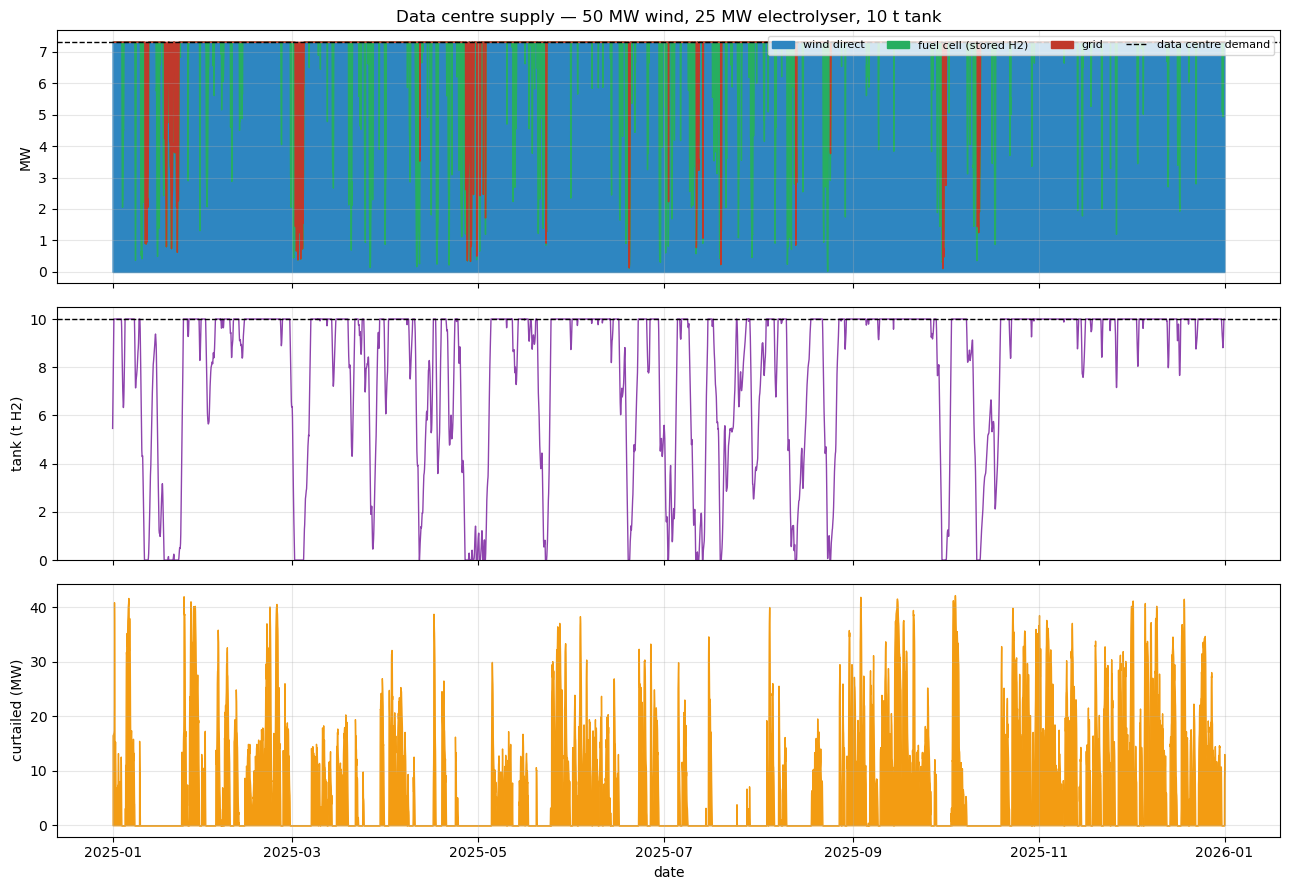

Saved to /Users/louis/lca-ai-project/ukelectrolyserlca/datacentre_hydrogen_outputs


In [6]:
import matplotlib.pyplot as plt
from pathlib import Path

show = dispatch.set_index("datetime")
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

axes[0].fill_between(show.index, 0, show.direct_kwh / DT_HOURS / 1000, color="#2e86c1", label="wind direct")
axes[0].fill_between(show.index, show.direct_kwh / DT_HOURS / 1000,
                     (show.direct_kwh + show.fuel_cell_kwh) / DT_HOURS / 1000,
                     color="#27ae60", label="fuel cell (stored H2)")
axes[0].fill_between(show.index, (show.direct_kwh + show.fuel_cell_kwh) / DT_HOURS / 1000,
                     (show.direct_kwh + show.fuel_cell_kwh + show.grid_kwh) / DT_HOURS / 1000,
                     color="#c0392b", label="grid")
axes[0].axhline(SYS_DC_DEMAND_MW, color="k", ls="--", lw=1, label="data centre demand")
axes[0].set_ylabel("MW"); axes[0].legend(loc="upper right", ncol=4, fontsize=8)
axes[0].set_title(f"Data centre supply — {SYS_WIND_CAPACITY_MW:g} MW wind, "
                  f"{SYS_ELECTROLYSER_MW:g} MW electrolyser, {SYS_TANK_CAPACITY_T:g} t tank")

axes[1].plot(show.index, show.soc_kg / 1000, color="#8e44ad", lw=1)
axes[1].axhline(SYS_TANK_CAPACITY_T, color="k", ls="--", lw=1)
axes[1].set_ylabel("tank (t H2)"); axes[1].set_ylim(0, SYS_TANK_CAPACITY_T * 1.05)

axes[2].fill_between(show.index, 0, show.curtailed_kwh / DT_HOURS / 1000, color="#f39c12")
axes[2].set_ylabel("curtailed (MW)"); axes[2].set_xlabel("date")
for a in axes: a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

out = Path("datacentre_hydrogen_outputs"); out.mkdir(exist_ok=True)
tag = f"{SYS_WIND_CAPACITY_MW:g}MWwind_{SYS_ELECTROLYSER_MW:g}MWely_{SYS_TANK_CAPACITY_T:g}tH2_{SYS_START}_{SYS_END}"
dispatch.to_csv(out / f"dispatch_{tag}.csv", index=False)
pd.Series({"wind_gwh": E.wind_generated_kwh/1e6, "direct_gwh": E.direct_kwh/1e6,
           "fuel_cell_gwh": E.fuel_cell_kwh/1e6, "grid_gwh": E.grid_kwh/1e6,
           "curtailed_gwh": E.curtailed_kwh/1e6, "h2_stored_t": E.h2_stored_kg/1000,
           "kt_co2e": total/1e6, "g_co2e_per_kwh": total/dc_total_kwh*1000},
          name="value").to_csv(out / f"summary_{tag}.csv")
print("Saved to", (out).resolve())

## Reading this

**Change any of the five sizes in `dashboard_config.py` and re-run.** The three
that interact most are wind capacity (how much surplus exists at all),
electrolyser rating (how fast surplus can be captured) and tank size (how long
it can be held). The output cells report tank utilisation and the number of
steps spent full or empty, which is the fastest way to see which of the three is
the binding constraint: a tank that never fills means the electrolyser is too
small or the wind too weak; a tank that sits full means you need more
electrolyser or more storage; a tank that sits empty means the wind farm is
undersized for the load.

**Curtailment is charged, not ignored.** The wind farm's carbon is applied to
everything it generates, so oversizing the farm to raise the hydrogen fraction
shows up as a rising cost rather than a free lunch. That is the honest
attributional treatment when the spilled electricity has nowhere to go. If your
scenario would export the surplus to the grid instead of spilling it, this
overstates the wind burden and the model should be changed to credit the export.

**The tank is a proxy.** Notebook 2's inventory is assembled from steel, not
taken from a published tank LCA, and the one literature range I found could not
be reconciled with it because its denominator was ambiguous. Storage capital is
usually a small share of the total here, so the headline is not very sensitive
to it — but check the tank line in the carbon breakdown before quoting any
number, and if it is large in your configuration, that proxy needs replacing
first.

**Still not counted:** the compressor hardware (its electricity *is* counted),
tank foundations and enclosure, hydrogen leakage — which matters, since hydrogen
is an indirect greenhouse gas — and end-of-life for any of it. All push the same
way, so treat the storage numbers as a floor.